<a href="https://colab.research.google.com/github/sonjoy1s/OIBSIP/blob/main/SMS_Spam_Collection_DatasetTask4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
#from catboost import CatBoostClassifier
#from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [37]:
df = pd.read_csv('/content/spam.csv', encoding='latin1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [39]:
df.isna().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [40]:
df.describe().T

,count,unique,top,freq
v1,5572,2,ham,4825
v2,5572,5169,"Sorry, I'll call later",30
Unnamed: 2,50,43,"bt not his girlfrnd... G o o d n i g h t . . .@""",3
Unnamed: 3,12,10,"MK17 92H. 450Ppw 16""",2
Unnamed: 4,6,5,"GNT:-)""",2


In [41]:
df.shape

(5572, 5)

In [42]:
df.nunique()

,0
v1,2
v2,5169
Unnamed: 2,43
Unnamed: 3,10
Unnamed: 4,5


In [43]:
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)

In [44]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


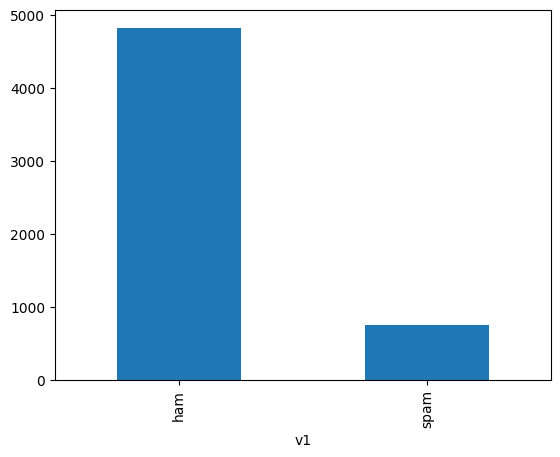

In [45]:
df['v1'].value_counts().plot(kind='bar')
plt.show()

In [46]:
le = LabelEncoder()
df['v1'] = le.fit_transform(df['v1'])


In [47]:
df.head()

,v1,v2
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


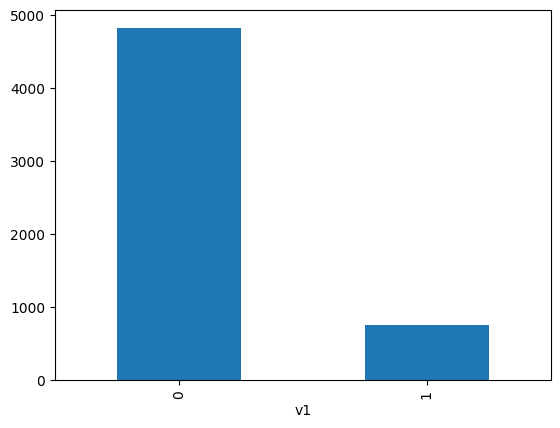

In [48]:
df['v1'].value_counts().plot(kind='bar')
plt.show()

In [49]:
X = df.drop(columns=['v1'],axis=1)
y = df['v1']

In [50]:
numerical_cols  = X.select_dtypes(include=np.number).columns

print(numerical_cols)

categorical_cols = X.select_dtypes(include=object).columns

print(categorical_cols)

Index([], dtype='object')
Index(['v2'], dtype='object')


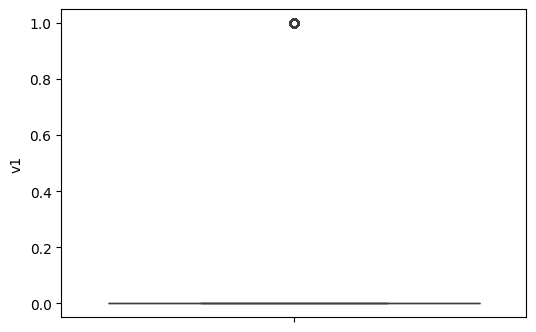

In [51]:
plt.figure(figsize=(6,4))
sns.boxplot(df['v1'])
plt.show()

In [52]:
#numerical Pipeline
numerical_pipe = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler',StandardScaler())
    ]
)

In [53]:
categorical_pipe = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('onehot',OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [54]:
#Combine numerical and categorical

from sklearn.compose import ColumnTransformer
Combine_pipe = ColumnTransformer([
    ('num',numerical_pipe,numerical_cols),
    ('cat',categorical_pipe,categorical_cols)
]
)

In [55]:
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size = 0.25 , random_state=42,stratify=y)

In [56]:
# base Learner
from sklearn.svm import SVC
lr = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
xgb = XGBClassifier()
sv = SVC(probability=True, random_state=42)


In [57]:
#voting Classification
voting_cls = VotingClassifier(
    estimators=[
        ('lr',lr),
        ('dt',dt),
        ('rf',rf),
        ('gb',gb),
        ('xgb',xgb),
        ('sv',sv)

    ],
    voting='hard'
)

In [58]:
#Stacking

stacking_cls = StackingClassifier(
    estimators=[
        ('lr',lr),
        ('dt',dt),
        ('rf',rf),
        ('gb',gb)
    ],
    final_estimator=LogisticRegression()
)

In [59]:
model_to_train = {
    'Logistic Regression':lr,
    'Decision Tree':dt,
    'Random Forest':rf,
    'Gradient Boosting':gb,
    'XGBoost':xgb,
    'Support Vector':sv,
    'Voting Classifier':voting_cls,
    'Stacking Classifier':stacking_cls
}

In [60]:
results = []
for model_name, model in model_to_train.items():
  print(f"--- Training and Evaluating {model_name} ---")
  pipe = Pipeline(
      steps=[
          ('combine', Combine_pipe),
          ('model', model)
      ]
  )
  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)

  accuracy = accuracy_score(y_test, y_pred)
  report = classification_report(y_test, y_pred)
  cm = confusion_matrix(y_test, y_pred)

  results.append({
      'model_name': model_name,
      'accuracy': accuracy,
      'classification_report': report,
      'confusion_matrix': cm
  })
  print(f"Accuracy for {model_name}: {accuracy:.4f}")
  print(f"Classification Report for {model_name}:\n{report}")
  print(f"Confusion Matrix for {model_name}:\n{cm}\n")

print("\n--- All Model Results Summary ---")
for res in results:
    print(f"Model: {res['model_name']}, Accuracy: {res['accuracy']:.4f}")

--- Training and Evaluating Logistic Regression ---
Accuracy for Logistic Regression: 0.8658
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      1206
           1       0.00      0.00      0.00       187

    accuracy                           0.87      1393
   macro avg       0.43      0.50      0.46      1393
weighted avg       0.75      0.87      0.80      1393

Confusion Matrix for Logistic Regression:
[[1206    0]
 [ 187    0]]

--- Training and Evaluating Decision Tree ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy for Decision Tree: 0.8923
Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      1206
           1       1.00      0.20      0.33       187

    accuracy                           0.89      1393
   macro avg       0.94      0.60      0.64      1393
weighted avg       0.90      0.89      0.86      1393

Confusion Matrix for Decision Tree:
[[1206    0]
 [ 150   37]]

--- Training and Evaluating Random Forest ---
Accuracy for Random Forest: 0.8923
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      1206
           1       1.00      0.20      0.33       187

    accuracy                           0.89      1393
   macro avg       0.94      0.60      0.64      1393
weighted avg       0.90      0.89      0.86      1393

Confusion Matrix for Random Forest:
[[1206    0]
 [ 150   37]]

--- Training and Eva

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Accuracy for Gradient Boosting: 0.8658
Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      1206
           1       0.00      0.00      0.00       187

    accuracy                           0.87      1393
   macro avg       0.43      0.50      0.46      1393
weighted avg       0.75      0.87      0.80      1393

Confusion Matrix for Gradient Boosting:
[[1206    0]
 [ 187    0]]

--- Training and Evaluating XGBoost ---
Accuracy for XGBoost: 0.8658
Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      1206
           1       0.00      0.00      0.00       187

    accuracy                           0.87      1393
   macro avg       0.43      0.50      0.46      1393
weighted avg       0.75      0.87      0.80      1393

Confusion Matrix for XGBoost:
[[1206    0]
 [ 187    0]]

--- Training and Evaluating Supp

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy for Voting Classifier: 0.8658
Classification Report for Voting Classifier:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      1206
           1       0.00      0.00      0.00       187

    accuracy                           0.87      1393
   macro avg       0.43      0.50      0.46      1393
weighted avg       0.75      0.87      0.80      1393

Confusion Matrix for Voting Classifier:
[[1206    0]
 [ 187    0]]

--- Training and Evaluating Stacking Classifier ---
Accuracy for Stacking Classifier: 0.8923
Classification Report for Stacking Classifier:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      1206
           1       1.00      0.20      0.33       187

    accuracy                           0.89      1393
   macro avg       0.94      0.60      0.64      1393
weighted avg       0.90      0.89      0.86      1393

Confusion Matrix for Stacking Classifier:
[[1206    0]

In [61]:
#voting Classification
model_lr = dt
pipe_lr = Pipeline(
    steps=[
        ('combine', Combine_pipe),
        ('model', model_lr)
    ]
)
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      1206
           1       1.00      0.20      0.33       187

    accuracy                           0.89      1393
   macro avg       0.94      0.60      0.64      1393
weighted avg       0.90      0.89      0.86      1393



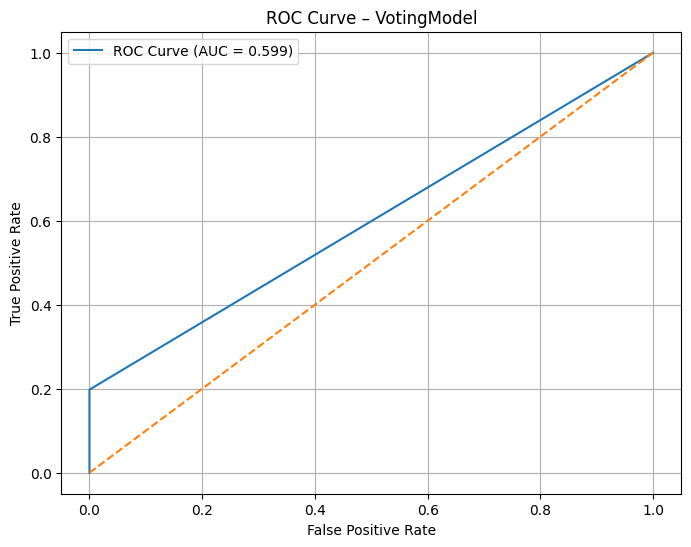

In [62]:
from sklearn.metrics import roc_curve, auc

y_prob_lr = pipe_lr.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – VotingModel")
plt.legend()
plt.grid(True)
plt.show()

In [63]:
from sklearn.model_selection import cross_val_score

In [64]:
lg_pipe = Pipeline(
    [
        ('preprocessor', Combine_pipe),
        ('model', dt)
    ]
)
cross_val = cross_val_score(lg_pipe,X_train,y_train,cv=5,scoring='accuracy')
print(cross_val)

[0.88755981 0.88516746 0.89114833 0.88397129 0.88502994]


In [65]:
print(cross_val.mean())

0.8865753660143827


In [66]:
print(cross_val.std())

0.0025703235407118683


In [67]:
cross_val_f1 = cross_val_score(lg_pipe, X_train, y_train, cv=5, scoring='f1_macro')
print("5-Fold CV F1 (macro):", cross_val_f1)
print("Mean F1:", cross_val_f1.mean())

5-Fold CV F1 (macro): [0.60798164 0.59391192 0.62833008 0.58671865 0.5938716 ]
Mean F1: 0.6021627779164925
